In [1]:
%reload_ext autoreload
%autoreload 2

import iminuit
from fastfeedback import *

# Loading the CAFs data

data_manager = DataManager("/storage/1/st15719/caf_new_sum.2.6M_weighted.root")

# Defining the binning for the true and reco energy and coszenith
Ebins = np.logspace(-1, 1, 200)
Czbins = np.linspace(-1, 1, 100)
Ebins_reco = np.logspace(-1, 1, 50)
Czbins_reco = np.linspace(-1, 1, 20)

latex_names = {
    Flavor.NuE: r"$\nu_e$",
    Flavor.NuMu: r"$\nu_\mu$",
    Flavor.NuMuBar: r"$\bar{\nu}_\mu$",
    Flavor.NuEBar: r"$\bar{\nu}_e$",
    Flavor.NuTau: r"$\bar{\nu}_\tau$",
    Flavor.NuTauBar: r"$\bar{\nu}_\tau$",
}

ktyr = 25
eff_exposure = 160000 / ktyr

method_combinations = [
    0b0000,
    0b0001,
    0b0010,
    0b0100,
    0b1000,
    0b1111,
    0b1110,
    0b1101,
    0b1011,
    0b0111,
]
method_combinations_nunubar_eff = [
    0b000,
    0b001,
    0b010,
    0b100,
    0b111,
    0b110,
    0b101,
    0b010,
]

Loading data...


/software/xn22103/miniconda/envs/dune-atmo-osc/lib/python3.12/site-packages/awkward/_nplikes/array_module.py:454: RuntimeWarning: invalid value encountered in cast
  return self._module.concatenate(arrays, axis=axis, casting="same_kind")


Finished loading data with unique indices


In [ ]:
def plot_hesse_errors_bdt(bdt_scores_path: str | None, results: list):
    direc_reco = Method.Reco
    energy_reco = Method.Reco
    flavor_disc = Method.Reco

    data_manager.set_direc_reco(direc_reco)
    data_manager.set_energy_reco(energy_reco)
    data_manager.set_flavor_discrimination(flavor_disc)
    data_manager.set_data_selection(data_manager.default_data_selection())

    if bdt_scores_path:
        nunubar_disc = Method.BDT
        bdt_scores = pl.read_csv(
            bdt_scores_path, schema={"event_index": pl.UInt32, "bdt_score": pl.Float64}
        )
        data_manager.attach_bdt_scores(bdt_scores)
    else:
        nunubar_disc = Method.Reco

    data_manager.set_nunubar_discrimination(nunubar_disc)
    data = data_manager.prepare_data()
    display(data)

    # Creating the events distribution
    events = EventDistrib(data, Ebins, Czbins, Ebins_reco, Czbins_reco)

    # Gets the standard oscillation parameters
    pars = get_nufit(MH.Normal)
    # Compute the events with the standard oscillation parameters
    events.compute_osc(pars)
    # Saving the reference event rates
    ref_event_rates = {
        fl: events.detected_events(fl) for fl in events.detected_channels
    }

    LnL_values = {fl: [] for fl in events.detected_channels}

    # Sampling dcp values
    sampling = np.linspace(0, 2 * np.pi, 50)
    for val in sampling:
        # Setting the dcp value
        pars.dcp = val
        # Computing the events with the new dcp value
        events.compute_osc(pars)
        # Saving the expected event rates
        expected = {fl: events.detected_events(fl) for fl in events.detected_channels}

        # Computing the LnL values
        for ch in events.detected_channels:
            LnL_values[ch].append(LnL(ref_event_rates[ch], expected[ch]))

    # Converting the lists to numpy arrays
    LnL_values = {fl: np.array(values) for fl, values in LnL_values.items()}

    def loss(dm21, dm31, th12, th13, th23, dcp):
        pars = ROOT.OscPars()
        pars.dm21 = dm21
        pars.dm31 = dm31
        pars.th12 = th12
        pars.th13 = th13
        pars.th23 = th23
        pars.dcp = dcp

        events.compute_osc(pars)
        # Saving the expected event rates
        expected = {fl: events.detected_events(fl) for fl in events.detected_channels}
        total_loss = sum(
            LnL(ref_event_rates[ch], expected[ch]) for ch in events.detected_channels
        )
        return total_loss

    nufit = get_nufit(MH.Normal)

    fitter = iminuit.Minuit(
        loss,
        dm21=nufit.dm21,
        dm31=nufit.dm31,
        th12=nufit.th12,
        th13=nufit.th13,
        th23=nufit.th23,
        dcp=nufit.dcp,
    )

    hesse = fitter.hesse()
    dcp_err = hesse.errors["dcp"]
    dcp_best_fit = hesse.values["dcp"]

    results.append(
        {
            "Nu-Nubar": nunubar_disc.name,
            "Nu-Nubar source": bdt_scores_path,
            "dCP Best Fit": dcp_best_fit,
            "dCP Error": dcp_err,
        }
    )


# to get the random.csv and bdt.csv files, see BDT-Skeleton.ipynb
results = []
plot_hesse_errors_bdt("random.csv", results)
plot_hesse_errors_bdt("bdt.csv", results)
plot_hesse_errors_bdt(None, results)

display(pl.DataFrame(results))

event_index,run,weight,flux_nue,flux_numu,xsec,nue_w,numu_w,osc_from_e_w,osc_from_mu_w,final_oscillated_w,genie_weight,nuPDG,Ev,isCC,NuMomY,mode,recoE_numu,recoE_nue,direc_numu,direc_nue,direc_nc,cvn_numu,cvn_nue,cvn_nc,npfps,direc_true,bdt_score,reco_pdg,recoE,direc_reco
u32,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i32,f32,bool,f32,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f32,f64,i32,f64,f64
0,0,2.4045136e7,0.002161,0.007993,3.63535,0.007857,0.029058,0.999988,0.000005,0.007857,2.4045136e7,-12,35.698929,true,5.325916,1,28.529816,28.432413,-0.167463,-0.291152,-0.291152,0.001684,0.994011,0.004305,9.0,-0.14919,0.17914,12,28.432413,-0.291152
1,0,6.0056676e7,700.832829,1458.73821,0.000058,0.040934,0.085202,0.815649,0.004269,0.033752,6.0056676e7,-12,0.425595,true,-0.055933,0,0.322256,0.208079,0.092648,0.092648,0.092648,0.001051,0.986669,0.01228,1.0,0.131423,0.443957,12,0.208079,0.092648
2,0,5.3239364e7,15.426308,37.089519,0.001919,0.0296,0.071168,0.009378,0.936898,0.066955,5.3239364e7,-14,1.668767,true,-0.83822,1,1.20171,1.156426,0.167917,0.169637,0.169637,0.982827,0.00081,0.016363,3.0,0.502299,0.478447,14,1.20171,0.167917
4,0,4.7361292e7,162.017806,343.329153,0.000198,0.0321,0.068023,0.021898,0.91852,0.063184,4.7361292e7,14,0.633065,true,-0.547973,0,0.5937,0.502835,0.568525,0.577708,0.577708,0.996696,0.000647,0.002657,2.0,0.865587,0.59407,-14,0.502835,0.577708
5,0,4.2285008e7,41.355044,92.242325,0.000658,0.027228,0.060732,0.00021,0.003651,0.000227,4.2285008e7,16,1.200049,false,1.047497,0,0.914734,0.299485,-0.333278,-0.333278,-0.333278,0.003598,0.002786,0.993616,1.0,-0.872879,0.480213,0,0.299485,-0.333278
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2884697,0,3.3414486e7,0.064264,0.176059,0.272591,0.017518,0.047992,0.000014,0.999613,0.047974,3.3414486e7,14,12.654237,true,3.211544,0,3.704717,0.893467,0.113819,0.130539,0.130539,0.968268,0.003848,0.027884,3.0,-0.253792,null,14,3.704717,0.113819
2884698,0,4.7914404e7,50.127813,115.380758,0.000596,0.029898,0.068818,0.054774,0.210969,0.016156,4.7914404e7,14,1.042722,false,-0.966394,0,2.243878,0.156685,0.899609,0.899609,0.899609,0.527526,0.001337,0.471137,1.0,0.926799,null,14,2.243878,0.899609
2884699,0,2.5720664e7,1042.373838,2071.887123,0.000018,0.018585,0.036942,0.001904,0.945746,0.034973,2.5720664e7,14,0.31196,true,0.274496,0,0.260973,0.169946,-0.396677,-0.396677,-0.396677,0.99478,0.001054,0.004166,1.0,-0.879909,null,14,0.260973,-0.396677


Filling histograms...
Using the following detected output channels: ['NuMuBar', 'NuEBar', 'NC', 'NuE', 'NuMu']
Finished filling histograms...


event_index,run,weight,flux_nue,flux_numu,xsec,nue_w,numu_w,osc_from_e_w,osc_from_mu_w,final_oscillated_w,genie_weight,nuPDG,Ev,isCC,NuMomY,mode,recoE_numu,recoE_nue,direc_numu,direc_nue,direc_nc,cvn_numu,cvn_nue,cvn_nc,npfps,direc_true,bdt_score,reco_pdg,recoE,direc_reco
u32,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i32,f32,bool,f32,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f32,f64,i32,f64,f64
0,0,2.4045136e7,0.002161,0.007993,3.63535,0.007857,0.029058,0.999988,0.000005,0.007857,2.4045136e7,-12,35.698929,true,5.325916,1,28.529816,28.432413,-0.167463,-0.291152,-0.291152,0.001684,0.994011,0.004305,9.0,-0.14919,0.553618,-12,28.432413,-0.291152
1,0,6.0056676e7,700.832829,1458.73821,0.000058,0.040934,0.085202,0.815649,0.004269,0.033752,6.0056676e7,-12,0.425595,true,-0.055933,0,0.322256,0.208079,0.092648,0.092648,0.092648,0.001051,0.986669,0.01228,1.0,0.131423,0.552717,-12,0.208079,0.092648
2,0,5.3239364e7,15.426308,37.089519,0.001919,0.0296,0.071168,0.009378,0.936898,0.066955,5.3239364e7,-14,1.668767,true,-0.83822,1,1.20171,1.156426,0.167917,0.169637,0.169637,0.982827,0.00081,0.016363,3.0,0.502299,0.359546,14,1.20171,0.167917
4,0,4.7361292e7,162.017806,343.329153,0.000198,0.0321,0.068023,0.021898,0.91852,0.063184,4.7361292e7,14,0.633065,true,-0.547973,0,0.5937,0.502835,0.568525,0.577708,0.577708,0.996696,0.000647,0.002657,2.0,0.865587,0.469792,14,0.5937,0.577708
5,0,4.2285008e7,41.355044,92.242325,0.000658,0.027228,0.060732,0.00021,0.003651,0.000227,4.2285008e7,16,1.200049,false,1.047497,0,0.914734,0.299485,-0.333278,-0.333278,-0.333278,0.003598,0.002786,0.993616,1.0,-0.872879,0.593784,0,0.299485,-0.333278
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2884697,0,3.3414486e7,0.064264,0.176059,0.272591,0.017518,0.047992,0.000014,0.999613,0.047974,3.3414486e7,14,12.654237,true,3.211544,0,3.704717,0.893467,0.113819,0.130539,0.130539,0.968268,0.003848,0.027884,3.0,-0.253792,null,14,3.704717,0.113819
2884698,0,4.7914404e7,50.127813,115.380758,0.000596,0.029898,0.068818,0.054774,0.210969,0.016156,4.7914404e7,14,1.042722,false,-0.966394,0,2.243878,0.156685,0.899609,0.899609,0.899609,0.527526,0.001337,0.471137,1.0,0.926799,null,14,2.243878,0.899609
2884699,0,2.5720664e7,1042.373838,2071.887123,0.000018,0.018585,0.036942,0.001904,0.945746,0.034973,2.5720664e7,14,0.31196,true,0.274496,0,0.260973,0.169946,-0.396677,-0.396677,-0.396677,0.99478,0.001054,0.004166,1.0,-0.879909,null,14,0.260973,-0.396677


Filling histograms...
Using the following detected output channels: ['NuMuBar', 'NuEBar', 'NC', 'NuE', 'NuMu']
Finished filling histograms...


event_index,run,weight,flux_nue,flux_numu,xsec,nue_w,numu_w,osc_from_e_w,osc_from_mu_w,final_oscillated_w,genie_weight,nuPDG,Ev,isCC,NuMomY,mode,recoE_numu,recoE_nue,direc_numu,direc_nue,direc_nc,cvn_numu,cvn_nue,cvn_nc,npfps,direc_true,bdt_score,reco_pdg,recoE,direc_reco
u32,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i32,f32,bool,f32,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f32,f64,i32,f64,f64
0,0,2.4045136e7,0.002161,0.007993,3.63535,0.007857,0.029058,0.999988,0.000005,0.007857,2.4045136e7,-12,35.698929,true,5.325916,1,28.529816,28.432413,-0.167463,-0.291152,-0.291152,0.001684,0.994011,0.004305,9.0,-0.14919,0.553618,12,28.432413,-0.291152
1,0,6.0056676e7,700.832829,1458.73821,0.000058,0.040934,0.085202,0.815649,0.004269,0.033752,6.0056676e7,-12,0.425595,true,-0.055933,0,0.322256,0.208079,0.092648,0.092648,0.092648,0.001051,0.986669,0.01228,1.0,0.131423,0.552717,12,0.208079,0.092648
2,0,5.3239364e7,15.426308,37.089519,0.001919,0.0296,0.071168,0.009378,0.936898,0.066955,5.3239364e7,-14,1.668767,true,-0.83822,1,1.20171,1.156426,0.167917,0.169637,0.169637,0.982827,0.00081,0.016363,3.0,0.502299,0.359546,14,1.20171,0.167917
4,0,4.7361292e7,162.017806,343.329153,0.000198,0.0321,0.068023,0.021898,0.91852,0.063184,4.7361292e7,14,0.633065,true,-0.547973,0,0.5937,0.502835,0.568525,0.577708,0.577708,0.996696,0.000647,0.002657,2.0,0.865587,0.469792,14,0.5937,0.577708
5,0,4.2285008e7,41.355044,92.242325,0.000658,0.027228,0.060732,0.00021,0.003651,0.000227,4.2285008e7,16,1.200049,false,1.047497,0,0.914734,0.299485,-0.333278,-0.333278,-0.333278,0.003598,0.002786,0.993616,1.0,-0.872879,0.593784,0,0.299485,-0.333278
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2884697,0,3.3414486e7,0.064264,0.176059,0.272591,0.017518,0.047992,0.000014,0.999613,0.047974,3.3414486e7,14,12.654237,true,3.211544,0,3.704717,0.893467,0.113819,0.130539,0.130539,0.968268,0.003848,0.027884,3.0,-0.253792,null,14,3.704717,0.113819
2884698,0,4.7914404e7,50.127813,115.380758,0.000596,0.029898,0.068818,0.054774,0.210969,0.016156,4.7914404e7,14,1.042722,false,-0.966394,0,2.243878,0.156685,0.899609,0.899609,0.899609,0.527526,0.001337,0.471137,1.0,0.926799,null,14,2.243878,0.899609
2884699,0,2.5720664e7,1042.373838,2071.887123,0.000018,0.018585,0.036942,0.001904,0.945746,0.034973,2.5720664e7,14,0.31196,true,0.274496,0,0.260973,0.169946,-0.396677,-0.396677,-0.396677,0.99478,0.001054,0.004166,1.0,-0.879909,null,14,0.260973,-0.396677


Filling histograms...
Using the following detected output channels: ['NC', 'NuE', 'NuMu']
Finished filling histograms...


Nu-Nubar,Nu-Nubar source,dCP Best Fit,dCP Error
str,str,f64,f64
"""BDT""","""random.csv""",3.700098,1.69837
"""BDT""","""bdt.csv""",3.700098,1.704643
"""Reco""",null,3.700098,1.868783


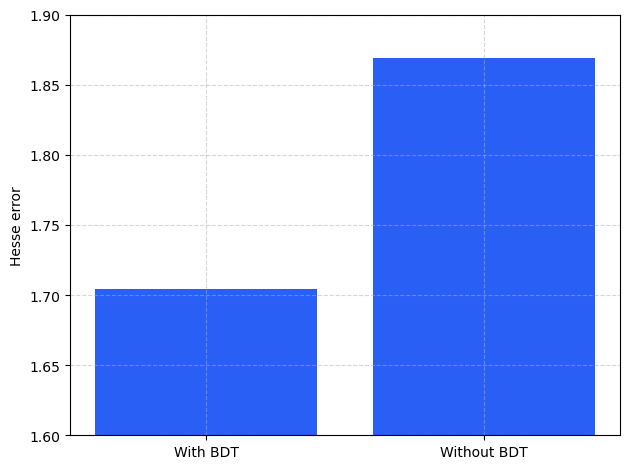

In [ ]:
plt.figure()
for r in results:
    source = r["Nu-Nubar source"]
    match source:
        case "random.csv":
            source = "Random scores"
            continue
        case "bdt.csv":
            source = "With BDT"
        case None:
            source = "Without BDT"

    plt.bar(
        f"{source}",
        r["dCP Error"],
        color="#295FF4",
    )
plt.ylabel("Hesse error")
plt.ylim(1.6, 1.9)
plt.grid(visible=True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("hesse-errors-bdt.svg")